In [1]:
import sys
import os

from pandas.core.common import random_state

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [3]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/A2AR/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'A2AR_mlp.csv')
df_existing = pd.read_csv(csv_filename)


In [4]:
df_existing = df_existing.sort_values(by="mcc", ascending=False)

In [5]:
display(df_existing)


,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
87,88,0.515408,0.982074,0.965475,26.072455,0.882347,25,0.000168,0.000003,927,64,RMSprop,1.00000,"[2000, 1000, 500]"
428,429,0.487938,0.984107,0.969174,468.780253,0.547017,193,0.006551,0.000281,1461,128,AdamW,0.00001,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
129,130,0.487938,0.984107,0.969174,1087.560843,0.108446,174,0.000010,0.009541,856,64,RMSprop,0.00001,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
150,151,0.461666,0.982813,0.966708,65.044459,0.264521,62,0.000031,0.005964,1144,64,RMSprop,0.00100,"[1000, 50]"
340,341,0.458086,0.977492,0.956843,17.015476,0.177368,42,0.010000,0.000569,1518,128,RMSprop,0.00010,[200]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,771,-0.024019,0.973418,0.948212,135.658166,0.258063,132,0.000295,0.002330,854,64,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
948,949,-0.025718,0.924917,0.860666,117.042086,0.757060,44,0.002442,0.000004,1587,64,AdamW,0.00010,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
928,929,-0.030761,0.919172,0.850801,694.707142,0.794516,179,0.000015,0.004715,1650,64,AdamW,0.00010,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
61,62,-0.174657,0.025157,0.044390,139.536410,0.565529,66,0.000054,0.000569,959,64,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"


In [6]:
display(df_existing.iloc[0])

run_id                             88
mcc                          0.515408
f1                           0.982074
acc                          0.965475
duration_seconds            26.072455
dropout_frac                 0.882347
patience                           25
tol                          0.000168
weight_decay                 0.000003
n_epochs                          927
batch_size                         64
optimizer                     RMSprop
lr                                1.0
neuron_layers       [2000, 1000, 500]
Name: 87, dtype: object

In [7]:
import random 
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

In [8]:
df_existing

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
87,88,0.515408,0.982074,0.965475,26.072455,0.882347,25,0.000168,0.000003,927,64,RMSprop,1.00000,"[2000, 1000, 500]"
428,429,0.487938,0.984107,0.969174,468.780253,0.547017,193,0.006551,0.000281,1461,128,AdamW,0.00001,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
129,130,0.487938,0.984107,0.969174,1087.560843,0.108446,174,0.000010,0.009541,856,64,RMSprop,0.00001,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
150,151,0.461666,0.982813,0.966708,65.044459,0.264521,62,0.000031,0.005964,1144,64,RMSprop,0.00100,"[1000, 50]"
340,341,0.458086,0.977492,0.956843,17.015476,0.177368,42,0.010000,0.000569,1518,128,RMSprop,0.00010,[200]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,771,-0.024019,0.973418,0.948212,135.658166,0.258063,132,0.000295,0.002330,854,64,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
948,949,-0.025718,0.924917,0.860666,117.042086,0.757060,44,0.002442,0.000004,1587,64,AdamW,0.00010,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
928,929,-0.030761,0.919172,0.850801,694.707142,0.794516,179,0.000015,0.004715,1650,64,AdamW,0.00010,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
61,62,-0.174657,0.025157,0.044390,139.536410,0.565529,66,0.000054,0.000569,959,64,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"


In [9]:
best_results = df_existing.iloc[:10]

In [10]:
best_results = best_results.iloc[:, 5:]

In [11]:
best_results_mlp_dicts = []
for i,j in best_results.iterrows():
    best_results_mlp_dicts.append(dict(j))

In [12]:
best_results_mlp_dicts

[{'dropout_frac': 0.882347062283631,
  'patience': 25,
  'tol': 0.0001676832936811,
  'weight_decay': 2.5595479226995334e-06,
  'n_epochs': 927,
  'batch_size': 64,
  'optimizer': 'RMSprop',
  'lr': 1.0,
  'neuron_layers': '[2000, 1000, 500]'},
 {'dropout_frac': 0.5470169726064936,
  'patience': 193,
  'tol': 0.0065512855685955,
  'weight_decay': 0.0002811768697974,
  'n_epochs': 1461,
  'batch_size': 128,
  'optimizer': 'AdamW',
  'lr': 1e-05,
  'neuron_layers': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.1084463262227956,
  'patience': 174,
  'tol': 1e-05,
  'weight_decay': 0.0095409547634999,
  'n_epochs': 856,
  'batch_size': 64,
  'optimizer': 'RMSprop',
  'lr': 1e-05,
  'neuron_layers': '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.2645209738448519,
  'patience': 62,
  'tol': 3.0888435964774785e-05,
  'weight_decay': 0.0059636233165946,
  'n_epochs': 1144,
  'batch_size': 64,
  'optimizer': 'RMSprop',
  'lr'

In [13]:

df_existing_svc = pd.read_csv("res/svc_res_val_1.1.csv")
display(df_existing_svc)
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :5]

best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))
    

,Unnamed: 0,C,coef0,degree,gamma,kernel,mcc,f1,acc
0,202,0.001,0.5,2,0.001,poly,0.509275,0.986111,0.972873
1,482,0.010,0.1,2,scale,poly,0.509275,0.986111,0.972873
2,102,0.001,0.1,2,auto,poly,0.476087,0.985489,0.971640
3,710,0.010,1.0,3,0.01,poly,0.461666,0.982813,0.966708
4,1094,0.100,1.0,3,0.01,poly,0.461666,0.982813,0.966708
...,...,...,...,...,...,...,...,...,...
2683,763,0.010,1.0,5,0.1,sigmoid,-0.105174,0.584289,0.419236
2684,983,0.100,0.5,2,1,sigmoid,-0.105498,0.613126,0.447596
2685,1007,0.100,0.5,3,1,sigmoid,-0.105498,0.613126,0.447596
2686,1031,0.100,0.5,4,1,sigmoid,-0.105498,0.613126,0.447596


In [14]:
best_results_svc_dicts

[{'C': 0.001, 'coef0': 0.5, 'degree': 2, 'gamma': '0.001', 'kernel': 'poly'},
 {'C': 0.01, 'coef0': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'},
 {'C': 0.001, 'coef0': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly'},
 {'C': 100.0, 'coef0': 0.1, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'},
 {'C': 0.01, 'coef0': 1.0, 'degree': 3, 'gamma': '0.01', 'kernel': 'poly'},
 {'C': 1000.0, 'coef0': 1.0, 'degree': 3, 'gamma': '0.01', 'kernel': 'poly'},
 {'C': 1000.0, 'coef0': 0.1, 'degree': 3, 'gamma': '0.001', 'kernel': 'poly'},
 {'C': 100.0, 'coef0': 1.0, 'degree': 3, 'gamma': '0.01', 'kernel': 'poly'},
 {'C': 100.0, 'coef0': 0.1, 'degree': 3, 'gamma': '0.001', 'kernel': 'poly'},
 {'C': 1000.0, 'coef0': 0.1, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'}]

In [15]:
df_existing_knn = pd.read_csv("res/knn_res_val_1.1.csv")
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]
best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

,0,1,2,3,4,5,6,7,8,9,...,3066,3067,3068,3069,3070,3071,3072,3073,3074,3075
0,0.629350,0.409822,0.114763,0.849649,-1.302256,-1.582738,-0.678928,-1.233195,-1.434335,-1.134524,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.233341
1,1.225274,0.942670,-0.168389,-0.169440,-0.341978,-0.052202,2.212653,0.803415,0.814574,0.266891,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,4.974340,-0.279983,-1.882446
2,-0.982475,0.726753,-1.033329,1.253848,-0.652347,0.063208,0.950025,-0.664100,-1.904197,-1.753757,...,-0.081803,2.465924,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,2.249445
3,1.324123,1.301264,0.499300,-2.170308,-0.573437,-1.556576,0.760613,0.555091,-0.346715,-0.279360,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,2.389444,-0.279983,-1.263797
4,0.402699,0.209699,0.333955,1.363094,-1.035884,-1.581501,-0.340915,-0.499982,-1.004890,-1.360252,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.151519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4629,1.032254,0.229924,0.599687,-2.032301,-0.221510,-0.969474,0.562910,0.238983,-1.371945,-0.892411,...,-0.081803,1.057649,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.090632
4630,0.852744,2.780378,-0.303757,0.045130,-0.705685,0.354237,2.359929,0.399819,-0.237312,-0.480343,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-0.886180
4631,1.077851,0.406309,0.009425,-2.073997,-0.936921,-0.010000,0.142849,-0.608348,-0.839790,-0.252830,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,0.321485
4632,0.728076,1.615808,0.402721,-0.872904,-0.449266,0.046455,1.877900,0.718067,-0.754062,-0.452396,...,-0.081803,1.411798,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.019934


'SVC'

0.5092747103416851

0.5092747103416851

0.47608652028040355

...

0.35201964210406944

0.35201964210406944

0.35201964210406944

0.35201964210406944

RESULTS FOR CYCLE KNN#1
Accuracy: 0.9144
F1-Score: 0.9547
MCC: 0.2073
RESULTS FOR CYCLE SVC#1
Accuracy: 0.9653
F1-Score: 0.9823
MCC: 0.1733


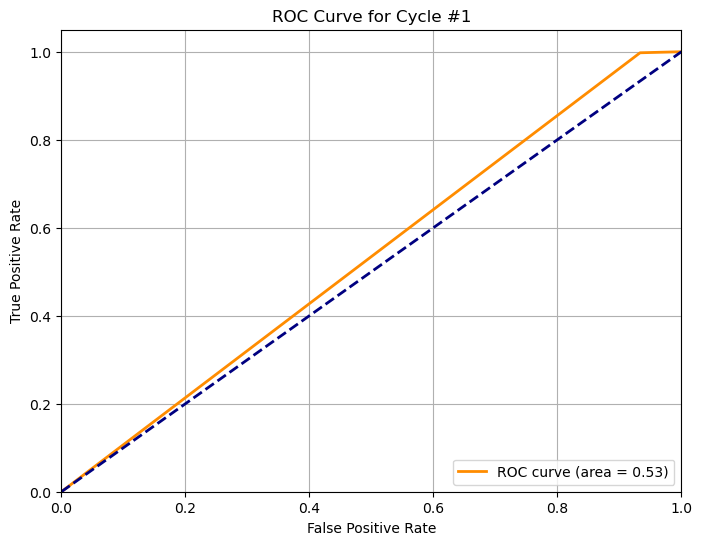

0.48353916858278984

0.4281145522322087

0.3423388817755015

0.3528998867964973

0.38933922849270686

...

0.30521619140858514

0.4498493064368867

0.474325549965871

0.39942885063401695

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.

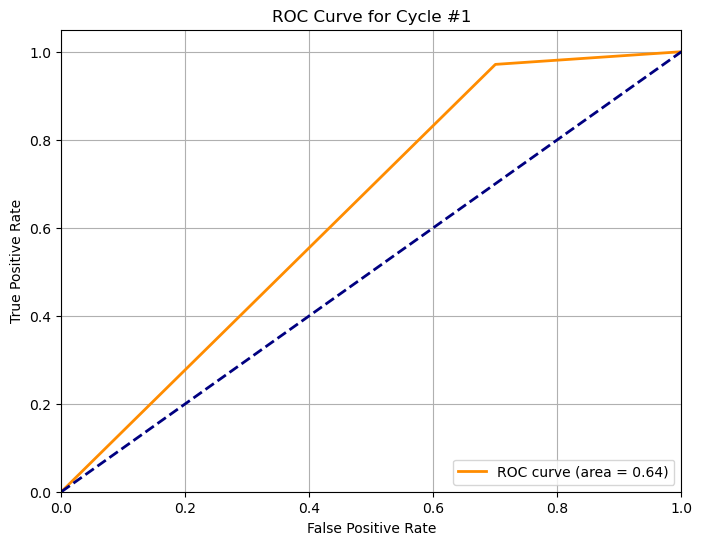

,0,1,2,3,4,5,6,7,8,9,...,3101,3102,3103,3104,3105,3106,3107,3108,3109,3110
0,0.614852,0.330676,0.061256,0.837094,-1.319899,-1.539319,-0.673249,-1.217038,-1.415040,-1.133207,...,-0.091516,-0.358200,-0.141092,-0.182966,-0.057735,-0.350158,-0.240235,-0.191718,-0.248616,1.219402
1,1.209993,0.845125,-0.214651,-0.153775,-0.324463,-0.003480,2.211092,0.785247,0.814249,0.288205,...,-0.091516,-0.358200,-0.141092,-0.182966,-0.057735,-0.350158,-0.240235,3.623632,-0.248616,-1.822675
2,0.211767,-0.688665,-0.517165,-0.683289,0.411144,-1.551053,0.374171,-0.372992,1.732635,-1.816459,...,-0.091516,2.312219,-0.141092,-0.182966,17.320508,-0.350158,-0.240235,-0.191718,-0.248616,-0.923079
3,0.060314,0.197603,0.753820,0.326293,2.148830,0.161366,-0.656600,-1.659636,-1.618224,-0.745663,...,-0.091516,-0.358200,-0.141092,-0.182966,-0.057735,-0.350158,-0.240235,-0.191718,-0.248616,0.599677
4,-1.525933,0.850339,0.917212,1.718658,0.698639,0.823724,-0.670906,-1.386386,-1.801228,0.171425,...,-0.091516,2.312219,-0.141092,-0.182966,-0.057735,-0.350158,-0.240235,-0.191718,-0.248616,1.477875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4633,1.114078,-0.876309,0.598649,-0.583646,1.316492,0.321739,0.239263,-0.321172,0.194456,-0.442994,...,-0.091516,-0.358200,-0.141092,-0.182966,-0.057735,-0.350158,-0.240235,2.152442,1.260171,0.799550
4634,0.988866,0.140656,0.778516,0.086155,0.450445,-0.706325,-0.625373,-0.209036,0.983956,0.238980,...,-0.091516,-0.358200,-0.141092,-0.182966,-0.057735,2.855853,-0.240235,-0.191718,-0.248616,-0.496913
4635,0.079432,1.315853,-1.044725,-0.116518,-1.255200,0.877721,-0.474598,-0.080828,-0.742685,-0.198902,...,-0.091516,-0.358200,-0.141092,-0.182966,-0.057735,-0.350158,-0.240235,-0.191718,-0.248616,0.841674
4636,1.105736,0.326251,0.091507,-1.790873,-0.893777,-0.036648,0.179896,-0.429690,-0.665425,0.100706,...,-0.091516,-0.358200,-0.141092,-0.182966,-0.057735,-0.350158,-0.240235,-0.191718,-0.248616,0.366675


'SVC'

0.199568892548734

0.199568892548734

0.199568892548734

...

0.36226017288635887

0.36226017288635887

0.36226017288635887

0.36226017288635887

RESULTS FOR CYCLE KNN#2
Accuracy: 0.9419
F1-Score: 0.9695
MCC: 0.3735
RESULTS FOR CYCLE SVC#2
Accuracy: 0.9670
F1-Score: 0.9829
MCC: 0.4749


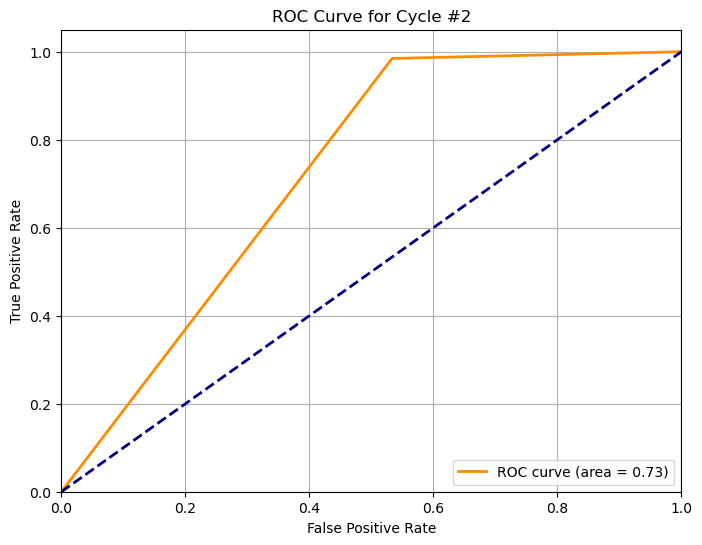

0.2314562752385814

0.4197948893974078

0.30743829722035665

0.33606092204030236

0.25632601422109447

...

0.2464976036268432

0.3442474159912704

0.40343364068993187

0.3958254269449715

[[0.9368588 ]
 [0.94141084]
 [0.94199353]
 [0.9412222 ]
 [0.9371083 ]
 [0.939801  ]
 [0.9368826 ]
 [0.9421171 ]
 [0.9414372 ]
 [0.94139725]
 [0.9417815 ]
 [0.94282645]
 [0.94324404]
 [0.9423382 ]
 [0.9422912 ]
 [0.9392134 ]
 [0.9424575 ]
 [0.94091815]
 [0.93764466]
 [0.9331942 ]
 [0.9422709 ]
 [0.9081749 ]
 [0.9405348 ]
 [0.935264  ]
 [0.9408597 ]
 [0.9408746 ]
 [0.94078964]
 [0.9385577 ]
 [0.9363057 ]
 [0.94143844]
 [0.93479204]
 [0.935983  ]
 [0.9429439 ]
 [0.9401348 ]
 [0.9338878 ]
 [0.93725765]
 [0.9408258 ]
 [0.9426294 ]
 [0.9349466 ]
 [0.9435909 ]
 [0.93989533]
 [0.94041467]
 [0.93667066]
 [0.94182414]
 [0.9338567 ]
 [0.9395237 ]
 [0.9376561 ]
 [0.05198041]
 [0.9412435 ]
 [0.94068253]
 [0.9433383 ]
 [0.9362534 ]
 [0.9385372 ]
 [0.93838185]
 [0.9436932 ]
 [0.9380471 ]
 [0.9377325 ]
 [0.9421048 ]
 [0.9381965 ]
 [0.93829846]
 [0.9386061 ]
 [0.9369603 ]
 [0.9409628 ]
 [0.9388952 ]
 [0.94318604]
 [0.9417574 ]
 [0.93393284]
 [0.940063  ]
 [0.9431991 ]
 [0.9387437 ]
 [0.03403724]
 [0.02

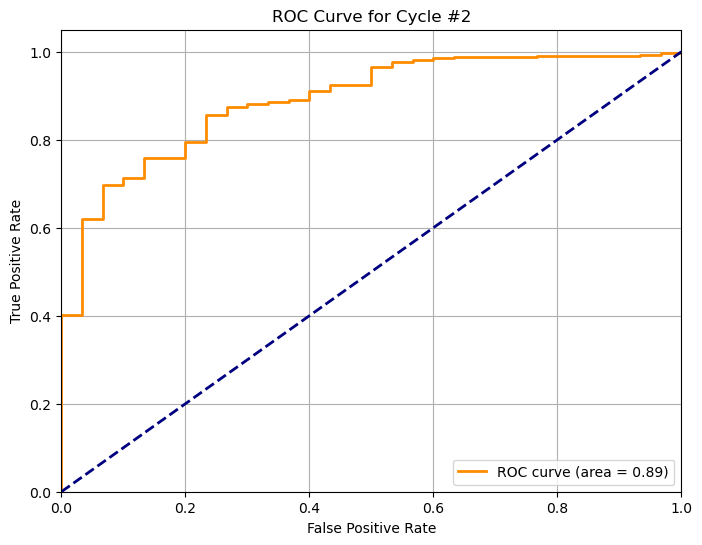

,0,1,2,3,4,5,6,7,8,9,...,3066,3067,3068,3069,3070,3071,3072,3073,3074,3075
0,0.583023,0.375493,0.127064,0.913303,-1.290388,-1.555416,-0.713767,-1.263729,-1.443834,-1.089554,...,-0.096023,-0.346247,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,-0.186502,-0.273866,1.299398
1,1.161008,0.903279,-0.152393,-0.064243,-0.306221,-0.044174,2.142568,0.773974,0.775040,0.319625,...,-0.096023,-0.346247,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,4.540823,-0.273866,-1.829253
2,-1.496051,0.908628,0.994031,1.783015,0.705299,0.769782,-0.711446,-1.436073,-1.828218,0.203851,...,-0.096023,2.360773,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,-0.186502,-0.273866,1.565227
3,1.256882,1.258466,0.506583,-1.983547,-0.543437,-1.529585,0.708228,0.525516,-0.370739,-0.229652,...,-0.096023,-0.346247,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,2.177161,-0.273866,-1.208050
4,0.363195,0.177272,0.343395,1.405818,-1.017389,-1.554196,-0.379873,-0.530123,-1.020124,-1.316533,...,-0.096023,-0.346247,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,-0.186502,-0.273866,1.217239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4631,1.445968,0.191991,0.363125,-0.870444,-0.548039,-0.072232,0.757864,0.173982,-0.352917,1.261952,...,-0.096023,-0.346247,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,-0.186502,-0.273866,0.316166
4632,0.699316,-0.012456,0.034787,-0.579619,-0.411630,-1.868662,0.187802,2.918695,1.880464,1.323513,...,10.414151,-0.346247,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,3.106806,-0.273866,-1.757574
4633,0.974652,0.547664,0.212548,-0.739853,-0.897529,-1.192066,0.055463,0.480863,-1.050731,-0.469687,...,-0.096023,-0.346247,-0.126624,-0.184174,-0.057735,-0.324182,-0.200929,-0.186502,-0.273866,-1.430484
4634,1.633030,-0.459857,-0.662210,-2.006487,-1.085136,1.138658,1.023239,0.341793,-1.076542,-0.556731,...,-0.096023,-0.346247,5.598337,-0.184174,-0.057735,-0.324182,-0.200929,-0.186502,-0.273866,0.032571


'SVC'

-0.006965234125687858

-0.006965234125687858

-0.006965234125687858

...

0.4298295119826988

0.4298295119826988

0.4298295119826988

0.4298295119826988

RESULTS FOR CYCLE KNN#3
Accuracy: 0.9450
F1-Score: 0.9712
MCC: 0.3683
RESULTS FOR CYCLE SVC#3
Accuracy: 0.9633
F1-Score: 0.9811
MCC: 0.3708


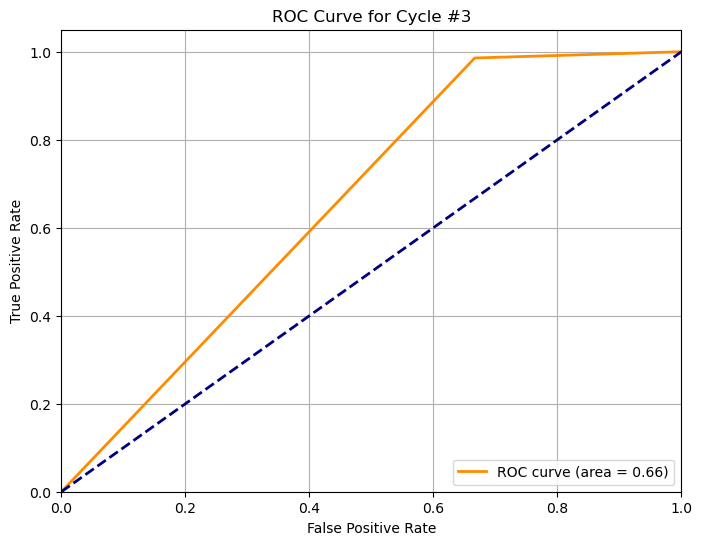

0.14757821863465487

0.2447044343953096

0.4036113703488831

0.320463241566372

0.2619666036217111

...

0.04486878106489951

0.34899431134137415

0.4094196391254858

0.28109260435187594

[[0.94598573]
 [0.8632185 ]
 [0.974063  ]
 [0.9921321 ]
 [0.98162615]
 [0.97325754]
 [0.9931536 ]
 [0.9805902 ]
 [0.6360345 ]
 [0.98437494]
 [0.9016225 ]
 [0.982333  ]
 [0.98624367]
 [0.9943144 ]
 [0.9817203 ]
 [0.99369097]
 [0.9766014 ]
 [0.99225825]
 [0.98439425]
 [0.9615265 ]
 [0.99163705]
 [0.993672  ]
 [0.48822728]
 [0.9265978 ]
 [0.9934889 ]
 [0.99094594]
 [0.98049253]
 [0.11477858]
 [0.99455464]
 [0.9954047 ]
 [0.9912226 ]
 [0.99200857]
 [0.9910964 ]
 [0.96525794]
 [0.99298567]
 [0.9901383 ]
 [0.83981836]
 [0.95703644]
 [0.98797625]
 [0.98769814]
 [0.98180526]
 [0.99327266]
 [0.9902671 ]
 [0.9799059 ]
 [0.9640242 ]
 [0.9239045 ]
 [0.9889416 ]
 [0.90333194]
 [0.9870035 ]
 [0.9885223 ]
 [0.98760253]
 [0.97643924]
 [0.9879473 ]
 [0.98680604]
 [0.9892569 ]
 [0.8785324 ]
 [0.9898101 ]
 [0.97329324]
 [0.9646521 ]
 [0.99473923]
 [0.9963445 ]
 [0.99315286]
 [0.97720474]
 [0.9673958 ]
 [0.9899339 ]
 [0.9607562 ]
 [0.7707017 ]
 [0.98535746]
 [0.99345255]
 [0.9907246 ]
 [0.9913674 ]
 [0.99

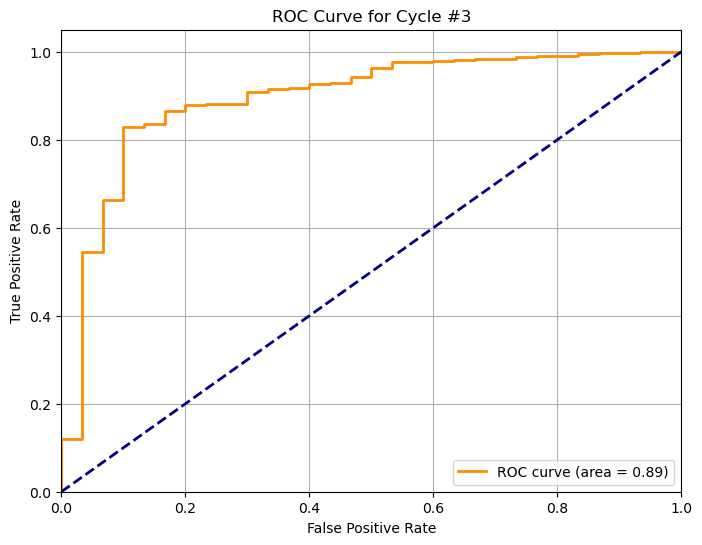

,0,1,2,3,4,5,6,7,8,9,...,3065,3066,3067,3068,3069,3070,3071,3072,3073,3074
0,0.598839,0.377257,0.111642,0.919226,-1.318346,-1.610838,-0.703586,-1.250548,-1.461400,-1.097151,...,-0.089124,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,-0.178180,-0.275421,1.294383
1,1.182709,0.909657,-0.164930,-0.111348,-0.335918,-0.071405,2.233025,0.792486,0.818218,0.298588,...,-0.089124,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,4.075199,-0.275421,-1.845914
2,-0.018951,0.522359,0.082052,-0.677612,1.302728,0.145114,-0.969877,-0.706378,0.005690,-1.253013,...,-0.089124,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,-0.178180,-0.275421,0.985999
3,1.279559,1.267949,0.487242,-2.134766,-0.572715,-1.584525,0.758373,0.543378,-0.358928,-0.245450,...,-0.089124,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,1.948510,-0.275421,-1.222398
4,0.376773,0.177302,0.325740,1.438458,-1.045830,-1.609595,-0.360309,-0.515023,-1.026091,-1.321965,...,-0.089124,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,-0.178180,-0.275421,1.211917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4637,-0.042644,-0.205812,0.362362,-0.187255,0.756770,0.251600,-1.078362,0.457325,-0.417029,-0.880964,...,-0.089124,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,-0.178180,-0.275421,0.072936
4638,1.610724,0.959735,0.940333,0.082919,0.972322,2.825655,-0.515431,-2.133714,-0.779180,0.154200,...,-0.089124,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,-0.178180,-0.275421,1.489266
4639,-0.552158,0.137149,-0.136280,0.344842,-1.262555,-0.025075,-0.609349,-0.462213,0.761456,-0.438202,...,8.774883,-0.336666,-0.131673,-0.185257,-0.057699,2.349308,2.813757,-0.178180,0.509187,-0.034831
4640,0.852036,-0.152082,-0.134773,-1.065343,-0.083574,-2.778118,0.003398,2.629536,1.425007,0.843072,...,11.220282,-0.336666,-0.131673,-0.185257,-0.057699,-0.323959,-0.239101,6.858585,-0.275421,-2.286837


'SVC'

0.541546278298034

0.5698713229785517

0.47587077179943654

...

0.376898287428283

0.376898287428283

0.376898287428283

0.376898287428283

RESULTS FOR CYCLE KNN#4
Accuracy: 0.9446
F1-Score: 0.9713
MCC: 0.1680
RESULTS FOR CYCLE SVC#4
Accuracy: 0.9649
F1-Score: 0.9822
MCC: -0.0063


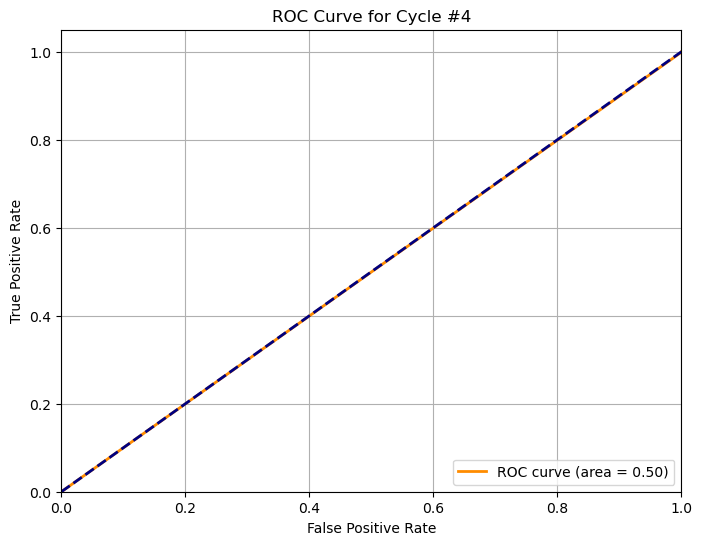

0.46329111972356135

0.5246377637571681

0.6188022897402026

0.5494936151475122

0.5200799132260737

...

0.22705102326213364

0.6204986062458954

0.6104671461894305

0.6204986062458954

[[0.9613957 ]
 [0.97010887]
 [0.97096574]
 [0.9680103 ]
 [0.9364078 ]
 [0.9248801 ]
 [0.965708  ]
 [0.9623382 ]
 [0.9599338 ]
 [0.91230065]
 [0.95991457]
 [0.97036195]
 [0.9599506 ]
 [0.96815586]
 [0.96102935]
 [0.95986724]
 [0.97155666]
 [0.96855295]
 [0.957135  ]
 [0.8662726 ]
 [0.96709645]
 [0.86259973]
 [0.8766857 ]
 [0.9619876 ]
 [0.9632752 ]
 [0.957925  ]
 [0.96944493]
 [0.9718096 ]
 [0.9683567 ]
 [0.9665003 ]
 [0.96198267]
 [0.96471435]
 [0.9608952 ]
 [0.95856166]
 [0.9360809 ]
 [0.9713163 ]
 [0.9346324 ]
 [0.94777536]
 [0.96854264]
 [0.96235245]
 [0.9712696 ]
 [0.97001094]
 [0.94980884]
 [0.0918498 ]
 [0.96578616]
 [0.968049  ]
 [0.95851916]
 [0.95289063]
 [0.96073866]
 [0.9630885 ]
 [0.9651195 ]
 [0.95959413]
 [0.9611888 ]
 [0.9691349 ]
 [0.9662113 ]
 [0.96867174]
 [0.9667007 ]
 [0.9620472 ]
 [0.96418023]
 [0.967198  ]
 [0.97247845]
 [0.95708686]
 [0.9615739 ]
 [0.9580247 ]
 [0.9728635 ]
 [0.97015655]
 [0.9677292 ]
 [0.96275187]
 [0.9705018 ]
 [0.9652245 ]
 [0.9670569 ]
 [0.96

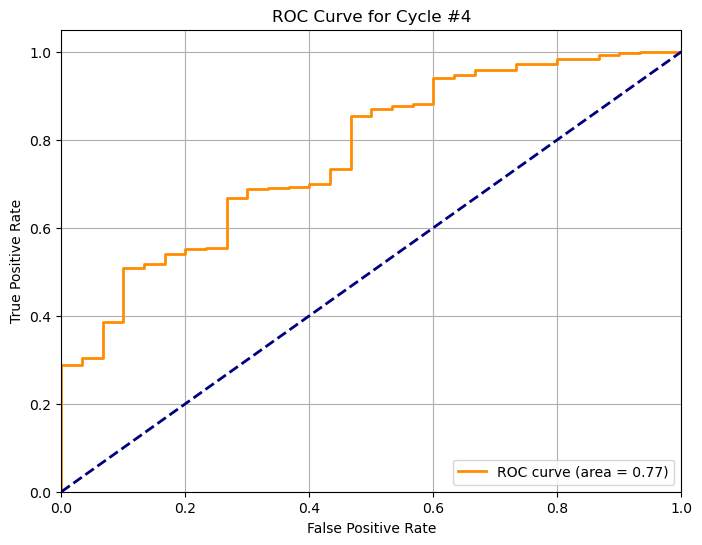

,0,1,2,3,4,5,6,7,8,9,...,3140,3141,3142,3143,3144,3145,3146,3147,3148,3149
0,0.604073,0.403877,0.092186,0.890887,-1.310843,-1.598163,-0.700492,-1.223980,-1.433907,-1.161091,...,-0.095544,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,-0.191616,-0.273276,1.254197
1,1.190073,0.937536,-0.185590,-0.113196,-0.318020,-0.065225,2.214257,0.786618,0.812770,0.290551,...,-0.095544,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,4.246584,-0.273276,-1.823984
2,0.058052,0.265835,0.789441,0.373274,2.148780,0.099310,-0.683667,-1.668416,-1.638676,-0.765306,...,-0.095544,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,-0.191616,-0.273276,0.627117
3,-1.705695,-0.628183,2.794567,1.401137,-0.711569,0.904778,-0.591689,-1.867550,-1.432667,0.428901,...,-0.095544,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,-0.191616,-0.273276,0.496875
4,1.287277,1.296676,0.469424,-2.084602,-0.557323,-1.571960,0.750583,0.541465,-0.347366,-0.275278,...,-0.095544,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,2.027484,-0.273276,-1.212802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4677,0.944711,0.660745,0.649607,-2.026553,-0.383898,-1.378601,0.800545,0.316601,-0.619955,-0.966252,...,-0.095544,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,-0.191616,-0.273276,-0.849153
4678,0.498496,0.268394,-0.531088,-1.399897,0.415477,-2.640631,-0.419702,3.032420,1.954109,0.209232,...,10.466396,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,8.439695,-0.273276,-2.391476
4679,-0.069510,0.196738,1.221151,0.198896,-0.666211,0.058021,0.523298,-0.201685,-0.138014,0.033068,...,-0.095544,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,-0.191616,-0.273276,1.365049
4680,0.502739,-0.000841,-0.694785,-1.315458,0.452227,-2.598755,-0.287294,2.897738,2.039013,0.527140,...,10.466396,-0.339019,-0.097711,-0.180821,-0.064256,-0.312999,-0.22089,8.518748,-0.273276,-2.362496


'SVC'

-0.010127142659300344

0.12169449762259246

0.1791480312312058

...

0.32875440857766575

0.32875440857766575

0.32875440857766575

0.32875440857766575

RESULTS FOR CYCLE KNN#5
Accuracy: 0.9448
F1-Score: 0.9710
MCC: 0.3898
RESULTS FOR CYCLE SVC#5
Accuracy: 0.9643
F1-Score: 0.9815
MCC: 0.4740


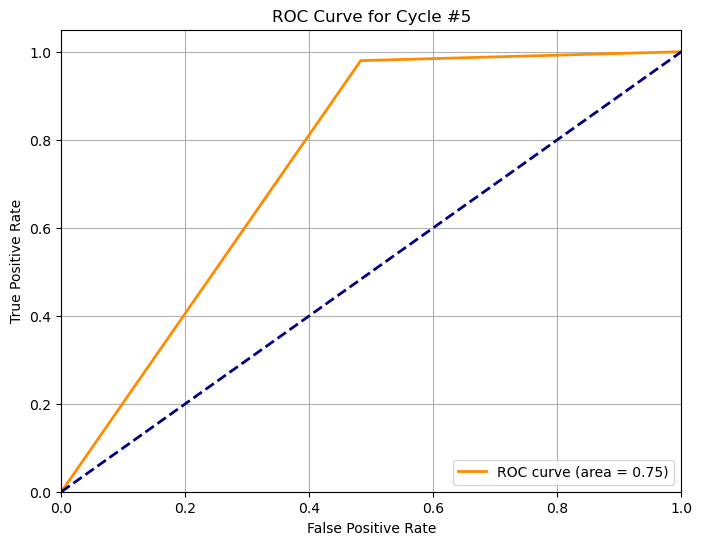

0.29366818407013523

0.32449263722112553

0.3491484596321141

0.26903381927447034

0.3006051133606386

...

0.38855215484928585

0.22858850026191668

0.2346308291008219

0.3592533916701553

[[1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.

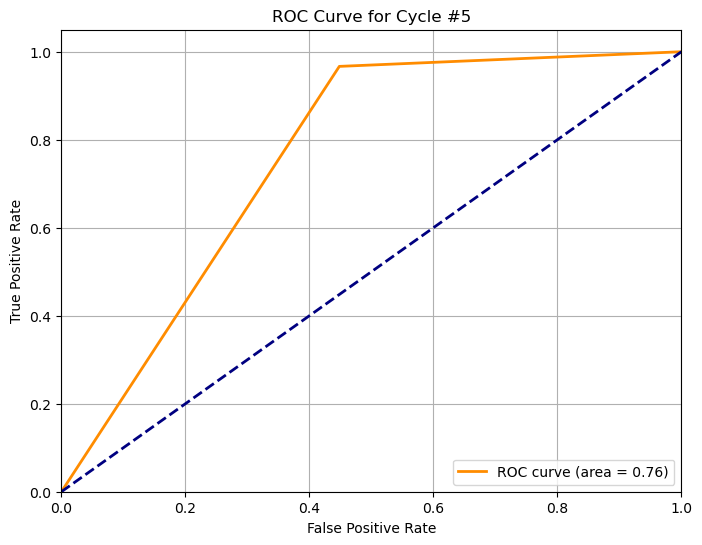

,0,1,2,3,4,5,6,7,8,9,...,3106,3107,3108,3109,3110,3111,3112,3113,3114,3115
0,0.575038,0.344754,0.135202,0.873553,-1.316038,-1.556806,-0.731682,-1.221931,-1.441971,-1.120083,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,-0.201717,-0.277882,1.270681
1,1.159837,0.863238,-0.146579,-0.122904,-0.331526,-0.045682,2.251201,0.777923,0.791730,0.294382,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,4.645487,-0.277882,-1.844796
2,0.030137,0.210638,0.842509,0.359871,2.114623,0.116512,-0.714465,-1.663992,-1.645557,-0.734433,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,-0.201717,-0.277882,0.636004
3,-1.016326,1.024385,-0.903793,-0.383481,0.975546,0.337580,0.626356,0.404997,1.754890,-0.584455,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,-0.201717,-0.277882,-0.163437
4,1.256841,1.212165,0.517877,-2.079337,-0.568826,-1.530977,0.753313,0.534080,-0.361706,-0.256955,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,2.221885,-0.277882,-1.226208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4667,1.211910,0.843676,0.588378,-1.098838,-0.371956,0.152437,-0.180738,1.339829,-0.677965,2.007656,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,-0.201717,-0.277882,0.613600
4668,-0.160720,1.939054,-1.664536,0.239717,-2.906405,-0.309785,0.222407,-0.312833,-0.953844,0.574053,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,-0.201717,-0.277882,-0.438257
4669,1.029115,0.600783,0.172783,-1.303971,-0.727736,-1.241621,0.240634,0.249743,-1.170255,-1.230254,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,0.098978,-0.277882,-1.035087
4670,0.959698,0.514046,0.532410,-0.892051,-0.275584,-0.882929,0.104424,1.280985,-0.692158,2.118564,...,-0.10202,-0.328658,-0.129451,-0.177339,-0.053783,-0.332799,-0.250278,-0.201717,-0.277882,0.268023


'SVC'

0.1217137566765101

0.1217137566765101

0.1217137566765101

...

0.49624060704041667

0.49624060704041667

0.49624060704041667

0.49624060704041667

RESULTS FOR CYCLE KNN#6
Accuracy: 0.9438
F1-Score: 0.9709
MCC: 0.1939
RESULTS FOR CYCLE SVC#6
Accuracy: 0.9622
F1-Score: 0.9806
MCC: 0.2307


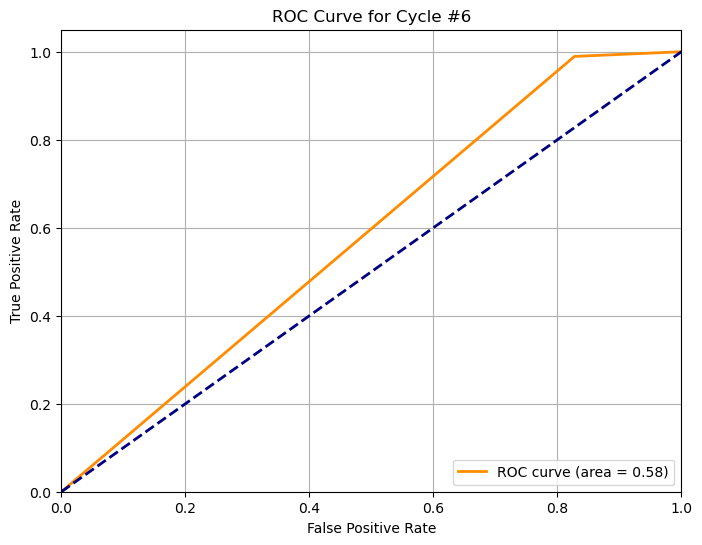

0.4471557482344626

0.5434244181023866

0.4198758352411297

0.549402390438247

0.3633797414921589

...

0.461058696194882

0.461058696194882

0.6102611925628749

0.4990166805629739

[[0.8799858 ]
 [0.9204455 ]
 [0.96131843]
 [0.96817756]
 [0.9623115 ]
 [0.9316489 ]
 [0.9037705 ]
 [0.9434206 ]
 [0.89373   ]
 [0.9448525 ]
 [0.83867514]
 [0.9616862 ]
 [0.9227222 ]
 [0.96477735]
 [0.95132434]
 [0.9583997 ]
 [0.93602216]
 [0.8911075 ]
 [0.96654594]
 [0.96038055]
 [0.95396096]
 [0.9384026 ]
 [0.96269584]
 [0.9531565 ]
 [0.94984066]
 [0.94631505]
 [0.93279713]
 [0.96157044]
 [0.95954585]
 [0.9287938 ]
 [0.91748804]
 [0.9590047 ]
 [0.96278733]
 [0.9483456 ]
 [0.9592803 ]
 [0.94958335]
 [0.93588763]
 [0.90910304]
 [0.8794675 ]
 [0.9341744 ]
 [0.9145671 ]
 [0.96820295]
 [0.8929067 ]
 [0.97114146]
 [0.7019696 ]
 [0.8062334 ]
 [0.9560855 ]
 [0.9538294 ]
 [0.9194934 ]
 [0.97278637]
 [0.96417224]
 [0.9439652 ]
 [0.76506716]
 [0.9254388 ]
 [0.9481905 ]
 [0.9456878 ]
 [0.95196444]
 [0.9060276 ]
 [0.94971526]
 [0.9408657 ]
 [0.9395756 ]
 [0.96233505]
 [0.83493674]
 [0.9449227 ]
 [0.94270015]
 [0.96036655]
 [0.95676804]
 [0.8960659 ]
 [0.96412337]
 [0.9679443 ]
 [0.9605708 ]
 [0.89

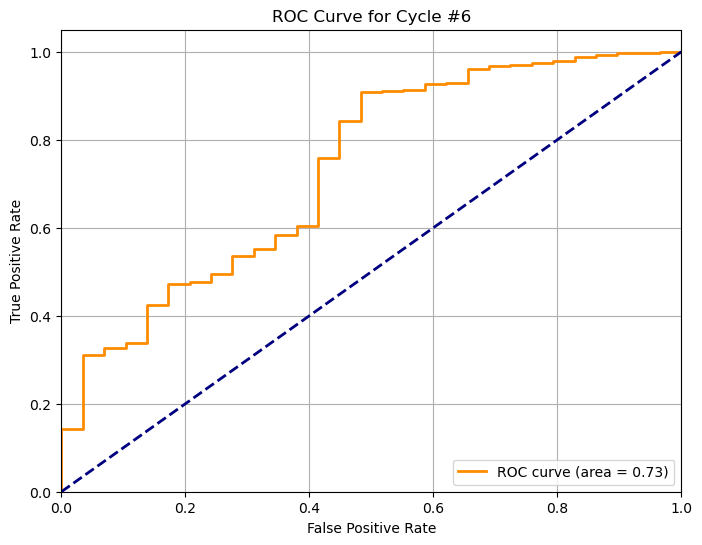

,0,1,2,3,4,5,6,7,8,9,...,3099,3100,3101,3102,3103,3104,3105,3106,3107,3108
0,0.606246,0.415358,0.084987,0.885003,-1.308033,-1.618558,-0.722699,-1.259184,-1.456271,-1.120962,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,-0.180456,-0.268587,1.270388
1,-0.665256,0.143698,0.309590,-0.500349,-0.770519,0.168341,-1.611391,-1.257197,-1.003587,1.655253,...,-0.073445,2.565244,-0.156602,-0.185973,-0.057555,-0.315222,3.544311,-0.180456,-0.268587,0.227356
2,1.194148,0.944604,-0.199061,-0.119404,-0.329288,-0.075652,2.210740,0.777723,0.815260,0.281444,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,4.677822,-0.268587,-1.858682
3,0.058454,0.278458,0.797985,0.367223,2.102533,0.089953,-0.705767,-1.709435,-1.663305,-0.738600,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,-0.180456,-0.268587,0.632941
4,1.291666,1.300774,0.470742,-2.091443,-0.565198,-1.592186,0.737681,0.529362,-0.357711,-0.265193,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,2.248683,-0.268587,-1.237395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4661,-0.029216,-0.608170,1.010506,1.228731,-0.422684,0.041366,-0.119097,-1.141055,-0.875805,0.557603,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,-0.180456,-0.268587,-0.385897
4662,0.980608,0.057472,0.851402,0.665130,0.910467,2.706970,-0.290456,-1.777539,-0.725290,0.360393,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,-0.180456,-0.268587,1.242872
4663,1.635141,-0.043070,-0.930214,-2.434770,-1.604026,1.138045,0.916132,0.249435,-1.453556,-0.317386,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,-0.180456,-0.268587,0.618265
4664,-0.043191,-0.586948,0.066787,-0.857015,1.072848,0.837547,0.895836,-1.859668,0.247374,1.079137,...,-0.073445,-0.351502,-0.156602,-0.185973,-0.057555,-0.315222,-0.235559,-0.180456,-0.268587,1.059666


'SVC'

-0.01577467602579118

-0.014100366402781525

0.0

...

0.15139839067776084

0.15139839067776084

0.15139839067776084

0.15139839067776084

RESULTS FOR CYCLE KNN#7
Accuracy: 0.9434
F1-Score: 0.9702
MCC: 0.4167
RESULTS FOR CYCLE SVC#7
Accuracy: 0.9572
F1-Score: 0.9777
MCC: 0.4799


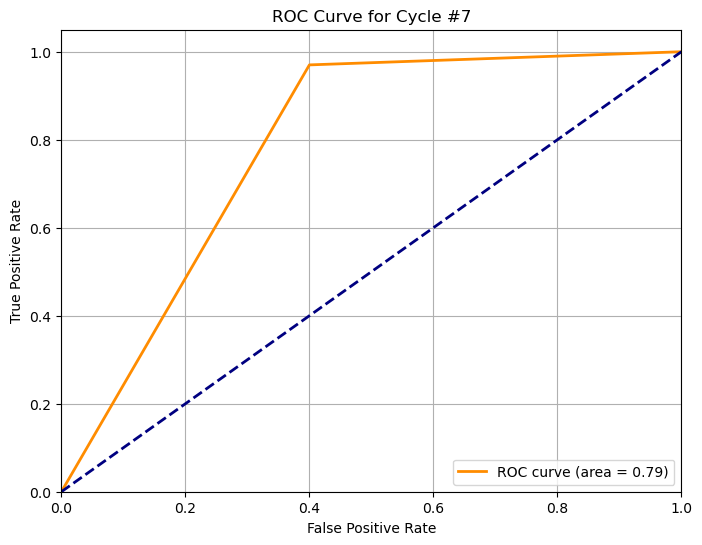

0.2650018525665716

0.2300368981260265

0.3635781879863754

0.23209601397199048

0.24070976719892706

...

0.12724665221395517

0.2695656778057907

0.27922673949510163

0.27832095872235335

[[0.9929671 ]
 [0.992961  ]
 [0.9936148 ]
 [0.9937416 ]
 [0.99284256]
 [0.99179876]
 [0.99340457]
 [0.99323905]
 [0.99334186]
 [0.99302   ]
 [0.99300635]
 [0.99325305]
 [0.9931618 ]
 [0.99321014]
 [0.99368966]
 [0.9929315 ]
 [0.9932087 ]
 [0.9529689 ]
 [0.9929904 ]
 [0.9934016 ]
 [0.9931583 ]
 [0.99324834]
 [0.99354136]
 [0.9918389 ]
 [0.9932115 ]
 [0.99279803]
 [0.03561502]
 [0.9933976 ]
 [0.99365085]
 [0.9908539 ]
 [0.9923361 ]
 [0.7293262 ]
 [0.99266535]
 [0.9937542 ]
 [0.50161487]
 [0.9933697 ]
 [0.9931537 ]
 [0.9936546 ]
 [0.9937126 ]
 [0.9931598 ]
 [0.99273235]
 [0.99246806]
 [0.9933257 ]
 [0.99359894]
 [0.9931051 ]
 [0.9934202 ]
 [0.99343055]
 [0.9932683 ]
 [0.03827715]
 [0.99311393]
 [0.99325985]
 [0.9929675 ]
 [0.9933469 ]
 [0.9927596 ]
 [0.9935747 ]
 [0.99219936]
 [0.99334246]
 [0.9908627 ]
 [0.99008185]
 [0.99329364]
 [0.9921748 ]
 [0.9931185 ]
 [0.9933154 ]
 [0.99317616]
 [0.9937755 ]
 [0.99369746]
 [0.9927152 ]
 [0.99331325]
 [0.99281454]
 [0.9919024 ]
 [0.99333763]
 [0.99

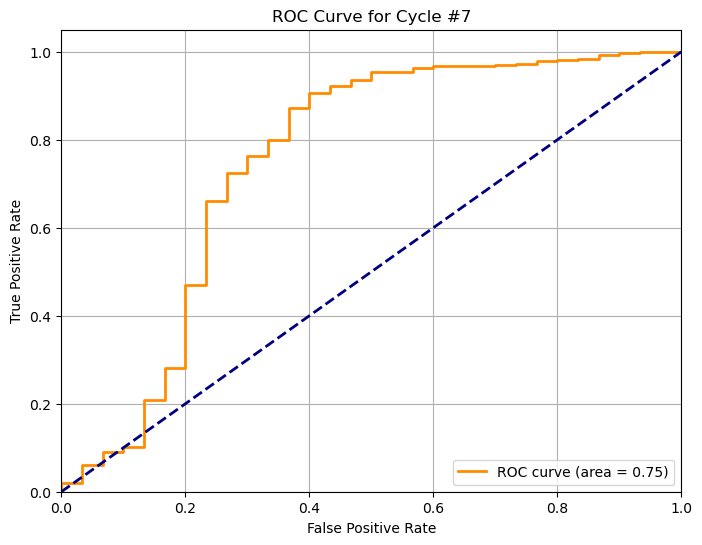

,0,1,2,3,4,5,6,7,8,9,...,3092,3093,3094,3095,3096,3097,3098,3099,3100,3101
0,0.566324,0.368487,0.115923,0.897660,-1.327796,-1.588574,-0.721730,-1.220033,-1.457604,-1.073938,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,-0.199622,-0.272605,1.227253
1,1.154835,0.897971,-0.172769,-0.094084,-0.344031,-0.074115,2.174956,0.784585,0.841120,0.300031,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,4.765081,-0.272605,-1.875225
2,-1.753340,-0.655496,2.924505,1.401640,-0.733989,0.884193,-0.613602,-1.861688,-1.456336,0.430979,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,-0.199622,-0.272605,0.463953
3,1.252455,1.254300,0.507986,-2.041264,-0.581151,-1.562688,0.720353,0.540161,-0.345893,-0.235521,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,2.282729,-0.272605,-1.259218
4,0.342493,0.169628,0.339405,1.397328,-1.054909,-1.587351,-0.383120,-0.498338,-1.018647,-1.295246,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,-0.199622,-0.272605,1.145781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4615,-0.473545,-1.018176,0.197752,-0.413668,0.806025,0.654794,-0.455568,0.052812,0.265658,-1.344191,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,-0.199622,-0.272605,0.306897
4616,1.996438,2.929781,-0.399694,0.360476,-1.154908,0.918502,-0.635873,-1.376994,-0.809494,0.456209,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,-0.199622,-0.272605,0.796510
4617,-0.214696,0.029216,1.599227,-0.004922,0.631853,0.741393,-1.081583,1.052585,-0.969073,0.479466,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,-0.199622,1.211040,1.550542
4618,0.374142,-1.048918,0.144000,-0.569359,1.405655,0.677790,-0.486612,-0.168581,0.186666,-1.417685,...,-0.098367,-0.339204,-0.141331,-0.177118,-0.054085,-0.327919,-0.230534,1.276681,-0.272605,0.368975


'SVC'

0.31829167735840913

0.3346937529635647

0.3769218104076232

...

0.36116393214316106

0.36116393214316106

0.36116393214316106

0.36116393214316106

RESULTS FOR CYCLE KNN#8
Accuracy: 0.9490
F1-Score: 0.9735
MCC: 0.2823
RESULTS FOR CYCLE SVC#8
Accuracy: 0.9592
F1-Score: 0.9790
MCC: 0.2383


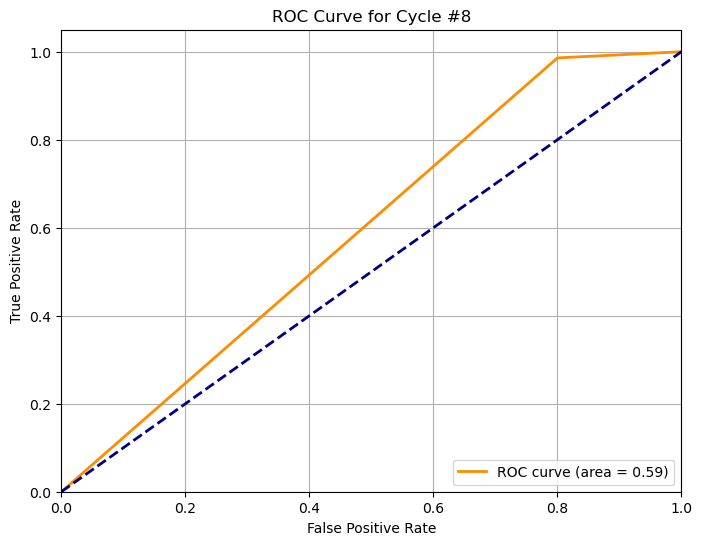

0.3524639425813775

0.5204222547739122

0.5886834367072441

0.5210478399863858

0.44348049787379606

...

0.3812895086584478

0.5127058232647389

0.5662320421454293

0.5435409205392543

[[0.98663205]
 [0.9910658 ]
 [0.99379736]
 [0.9948323 ]
 [0.9956216 ]
 [0.9947371 ]
 [0.9956606 ]
 [0.9926663 ]
 [0.9942409 ]
 [0.99380314]
 [0.9955634 ]
 [0.9956118 ]
 [0.9945034 ]
 [0.9954087 ]
 [0.9950106 ]
 [0.99520254]
 [0.9873842 ]
 [0.99450254]
 [0.99022794]
 [0.99589694]
 [0.9945135 ]
 [0.99556893]
 [0.99448895]
 [0.99576366]
 [0.9856574 ]
 [0.9951627 ]
 [0.99564916]
 [0.04542081]
 [0.9956267 ]
 [0.9956591 ]
 [0.9948895 ]
 [0.99486995]
 [0.9231074 ]
 [0.9940753 ]
 [0.9946302 ]
 [0.9941136 ]
 [0.9857495 ]
 [0.9959001 ]
 [0.9958419 ]
 [0.9949633 ]
 [0.99596786]
 [0.99548185]
 [0.991231  ]
 [0.9944577 ]
 [0.9954881 ]
 [0.992547  ]
 [0.9942532 ]
 [0.99542725]
 [0.99106795]
 [0.9951599 ]
 [0.995574  ]
 [0.99317884]
 [0.9939773 ]
 [0.9936406 ]
 [0.9953187 ]
 [0.99251854]
 [0.99524045]
 [0.9941087 ]
 [0.9943685 ]
 [0.9927402 ]
 [0.99549556]
 [0.99433124]
 [0.99615246]
 [0.99114823]
 [0.99529356]
 [0.9932613 ]
 [0.9956487 ]
 [0.99598444]
 [0.9929939 ]
 [0.9925581 ]
 [0.99567586]
 [0.98

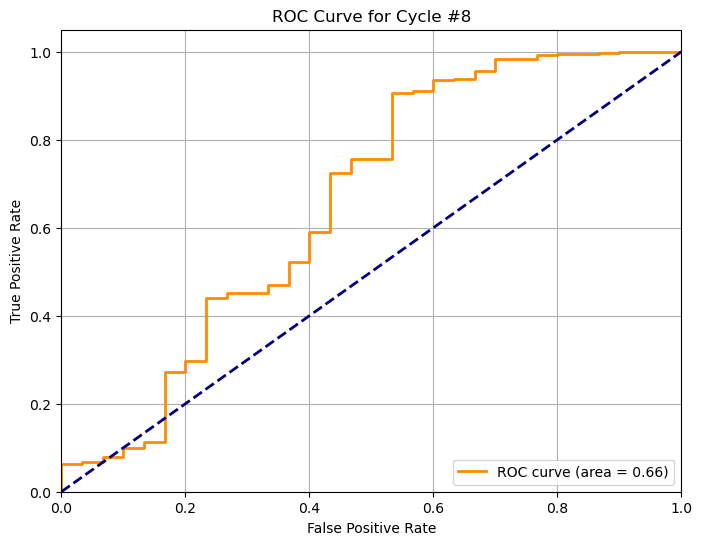

,0,1,2,3,4,5,6,7,8,9,...,3077,3078,3079,3080,3081,3082,3083,3084,3085,3086
0,0.582636,0.380961,0.081656,0.875374,-1.317888,-1.557286,-0.746788,-1.285951,-1.469098,-1.125827,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,-0.195962,-0.276720,1.267764
1,1.153836,0.927360,-0.201598,-0.106322,-0.314404,-0.029589,2.176117,0.770163,0.787145,0.277933,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,4.160768,-0.276720,-1.805153
2,-1.472031,0.932898,0.960404,1.748777,0.716970,0.793229,-0.744413,-1.459852,-1.859957,0.162604,...,-0.096387,2.670853,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,-0.195962,-0.276720,1.528857
3,1.248585,1.295074,0.466333,-2.033773,-0.556276,-1.531174,0.708348,0.519460,-0.377931,-0.269232,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,1.982403,-0.276720,-1.195016
4,0.365389,0.175749,0.300928,1.369979,-1.039531,-1.556052,-0.405113,-0.545717,-1.038252,-1.351934,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,-0.195962,-0.276720,1.187068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4593,0.957941,-0.646601,-0.992739,-0.768777,2.633332,-0.152140,-0.831527,-1.961613,-0.516358,-1.316118,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,-0.195962,-0.276720,1.349156
4594,0.157427,-0.919443,-0.341664,-0.463929,1.026224,0.126754,-0.506295,0.214778,0.331350,-1.266899,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,-0.195962,-0.276720,-0.149749
4595,0.780438,0.933200,-0.264398,0.217675,0.331172,1.289786,-0.227828,0.378997,-1.583182,-0.861736,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,-0.195962,-0.080152,-0.012963
4596,1.003858,0.495176,0.453704,-1.541527,-0.573099,-1.487994,0.654593,0.290280,-1.202827,-0.767007,...,-0.096387,-0.348702,-0.150594,-0.182456,-0.054198,-0.323955,-0.259168,-0.195962,-0.276720,-0.602312


'SVC'

0.17274686625753088

0.2349831339314793

0.17274686625753088

...

0.47492948370093585

0.47492948370093585

0.47492948370093585

0.47492948370093585

RESULTS FOR CYCLE KNN#9
Accuracy: 0.9237
F1-Score: 0.9599
MCC: 0.1865
RESULTS FOR CYCLE SVC#9
Accuracy: 0.9510
F1-Score: 0.9747
MCC: 0.2203


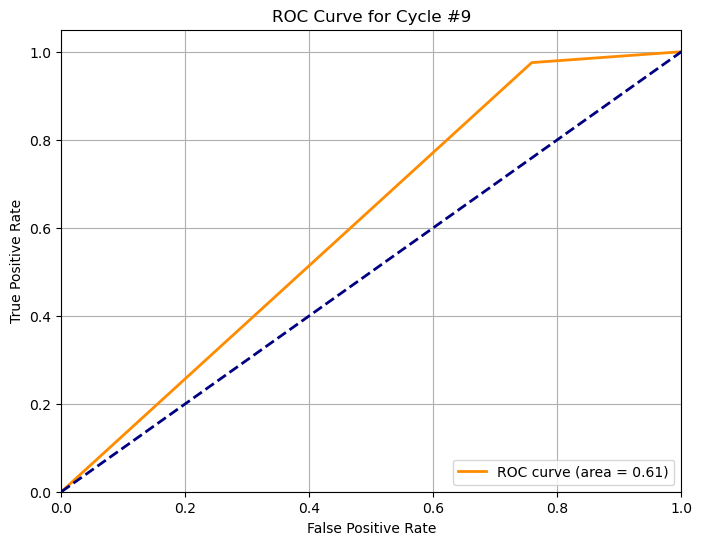

0.5833853926513112

0.6406770019851293

0.5308250341498886

0.5402298412297685

0.5202441312355689

...

0.3844615472847695

0.623936103750818

0.6618037067637184

0.6108627394870791

[[0.96871156]
 [0.9776234 ]
 [0.9077252 ]
 [0.9819264 ]
 [0.9611366 ]
 [0.9389589 ]
 [0.9815812 ]
 [0.970014  ]
 [0.95096684]
 [0.9739102 ]
 [0.97670627]
 [0.9793011 ]
 [0.9486518 ]
 [0.96855855]
 [0.97647995]
 [0.11671807]
 [0.98078203]
 [0.9746149 ]
 [0.91301805]
 [0.9842592 ]
 [0.9832722 ]
 [0.9778349 ]
 [0.900846  ]
 [0.97732097]
 [0.97904825]
 [0.9542049 ]
 [0.90310216]
 [0.9813338 ]
 [0.9788639 ]
 [0.96027905]
 [0.96505696]
 [0.9594822 ]
 [0.9616566 ]
 [0.9834841 ]
 [0.9633156 ]
 [0.9645314 ]
 [0.97085774]
 [0.9827132 ]
 [0.95650125]
 [0.9394889 ]
 [0.96146685]
 [0.66926223]
 [0.8717773 ]
 [0.9732039 ]
 [0.9744776 ]
 [0.9590375 ]
 [0.9751092 ]
 [0.9716798 ]
 [0.892985  ]
 [0.97371835]
 [0.97660655]
 [0.9533836 ]
 [0.9653149 ]
 [0.97462547]
 [0.876108  ]
 [0.9770932 ]
 [0.9655272 ]
 [0.97585845]
 [0.98511744]
 [0.96888196]
 [0.96507037]
 [0.91686845]
 [0.95249486]
 [0.95837635]
 [0.97678876]
 [0.9367499 ]
 [0.98079944]
 [0.9821098 ]
 [0.96595097]
 [0.97891986]
 [0.9654755 ]
 [0.45

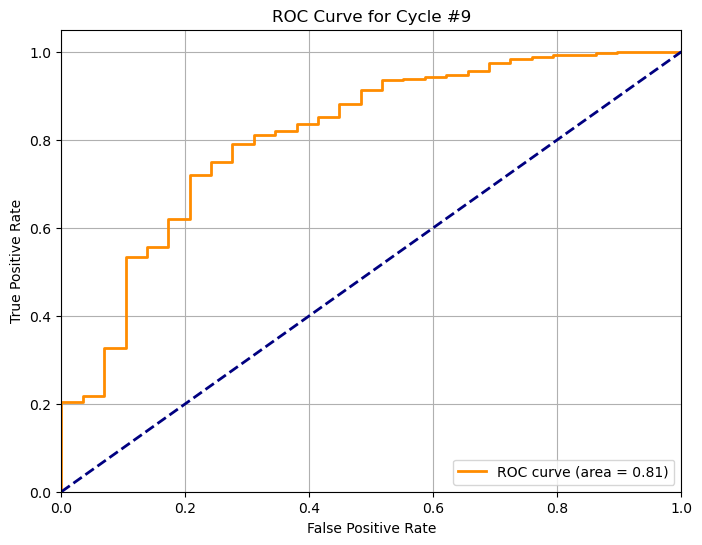

,0,1,2,3,4,5,6,7,8,9,...,3159,3160,3161,3162,3163,3164,3165,3166,3167,3168
0,0.616059,0.399520,0.055527,0.850004,-1.344703,-1.592465,-0.666400,-1.165879,-1.349826,-1.159313,...,-0.098408,-0.353413,-0.147411,-0.183359,-0.061378,-0.280575,-0.230992,-0.188899,-0.273604,1.215614
1,-0.655303,0.122129,0.270805,-0.510135,-0.789851,0.175936,-1.556707,-1.163969,-0.911676,1.665699,...,-0.098408,2.286723,-0.147411,-0.183359,-0.061378,-0.280575,3.669850,-0.188899,-0.273604,0.208556
2,0.068328,0.259732,0.738920,0.341647,2.175874,0.098360,-0.649437,-1.598576,-1.550214,-0.770230,...,-0.098408,-0.353413,-0.147411,-0.183359,-0.061378,-0.280575,-0.230992,-0.188899,-0.273604,0.600153
3,-0.983573,1.107897,-0.948338,-0.393999,1.006942,0.321741,0.671555,0.426587,1.796799,-0.618917,...,-0.098408,-0.353413,-0.147411,-0.183359,-0.061378,-0.280575,-0.230992,-0.188899,-0.273604,-0.175083
4,-0.005927,0.546807,0.026399,-0.677965,1.350773,0.149230,-0.932887,-0.644493,0.065123,-1.318673,...,-0.098408,-0.353413,-0.147411,-0.183359,-0.061378,-0.280575,-0.230992,-0.188899,-0.273604,0.918931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4611,-0.025507,0.612216,0.956958,0.139009,-0.985312,-1.981637,0.833830,1.172225,0.671979,-0.009374,...,-0.098408,-0.353413,-0.147411,-0.183359,-0.061378,-0.280575,-0.230992,-0.188899,-0.273604,-0.061245
4612,0.617213,0.429344,-0.649007,0.343473,-0.295260,-0.454038,-0.493367,0.643585,0.459330,0.082942,...,-0.098408,-0.353413,-0.147411,-0.183359,-0.061378,1.093600,-0.230992,-0.188899,2.068602,-0.326683
4613,0.992440,-0.175026,-0.003358,-0.962550,-0.273975,-2.793916,0.149105,2.460931,1.226629,0.958742,...,10.161736,-0.353413,-0.147411,-0.183359,-0.061378,-0.280575,-0.230992,6.749046,-0.273604,-2.189672
4614,1.125849,0.631376,0.009230,-1.195145,-0.815665,-1.347424,0.512238,0.387817,-0.958015,-0.907404,...,-0.098408,-0.353413,-0.147411,-0.183359,-0.061378,-0.280575,-0.230992,-0.188899,-0.273604,-1.233760


'SVC'

0.4778228211201421

0.4428536204380321

0.3639538820773332

...

0.31701134124376557

0.31701134124376557

0.31701134124376557

0.31701134124376557

RESULTS FOR CYCLE KNN#10
Accuracy: 0.9057
F1-Score: 0.9500
MCC: 0.1294
RESULTS FOR CYCLE SVC#10
Accuracy: 0.9678
F1-Score: 0.9836
MCC: 0.1796


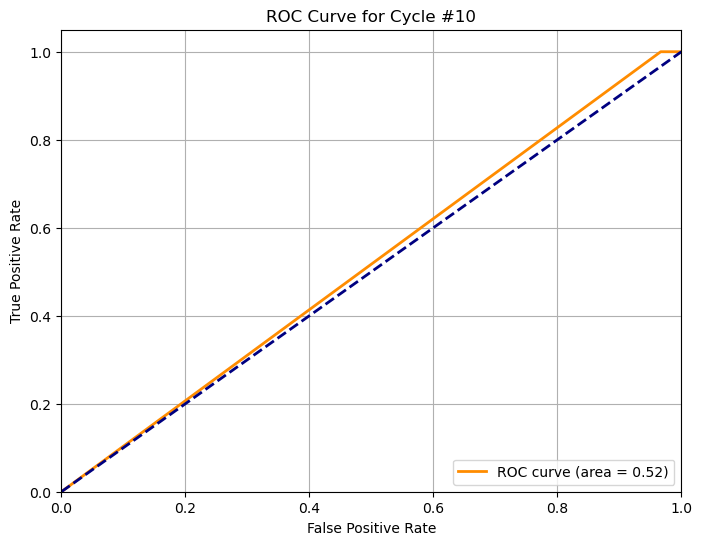

0.36916795711395234

0.43270428207718453

0.5210750039339226

0.44275180560088895

0.4719796608263411

...

0.39062387865957

0.530089312980791

0.40758515404344775

0.4217319973402383

[[0.9270615 ]
 [0.93846804]
 [0.9141933 ]
 [0.9371241 ]
 [0.9376102 ]
 [0.92849165]
 [0.93284917]
 [0.9158328 ]
 [0.12459832]
 [0.88380766]
 [0.93380505]
 [0.93563306]
 [0.93911606]
 [0.9383895 ]
 [0.8780991 ]
 [0.9416617 ]
 [0.9358436 ]
 [0.9188493 ]
 [0.9412635 ]
 [0.07172477]
 [0.9333894 ]
 [0.93040526]
 [0.9227098 ]
 [0.94218254]
 [0.9108265 ]
 [0.93591064]
 [0.9406226 ]
 [0.16390808]
 [0.9375821 ]
 [0.93729967]
 [0.8659926 ]
 [0.92505014]
 [0.4468856 ]
 [0.9440847 ]
 [0.93576634]
 [0.939148  ]
 [0.92673707]
 [0.9389911 ]
 [0.93302435]
 [0.93077314]
 [0.93439204]
 [0.9440406 ]
 [0.94410884]
 [0.93807334]
 [0.9351098 ]
 [0.90452147]
 [0.9244122 ]
 [0.8643674 ]
 [0.9426828 ]
 [0.9371361 ]
 [0.9356724 ]
 [0.9426922 ]
 [0.92896324]
 [0.9361646 ]
 [0.92892987]
 [0.9382252 ]
 [0.9363518 ]
 [0.9349054 ]
 [0.9391937 ]
 [0.9231608 ]
 [0.93715256]
 [0.94529665]
 [0.93841994]
 [0.93500596]
 [0.9304853 ]
 [0.93442416]
 [0.940701  ]
 [0.9327156 ]
 [0.89223796]
 [0.9238426 ]
 [0.93344116]
 [0.88

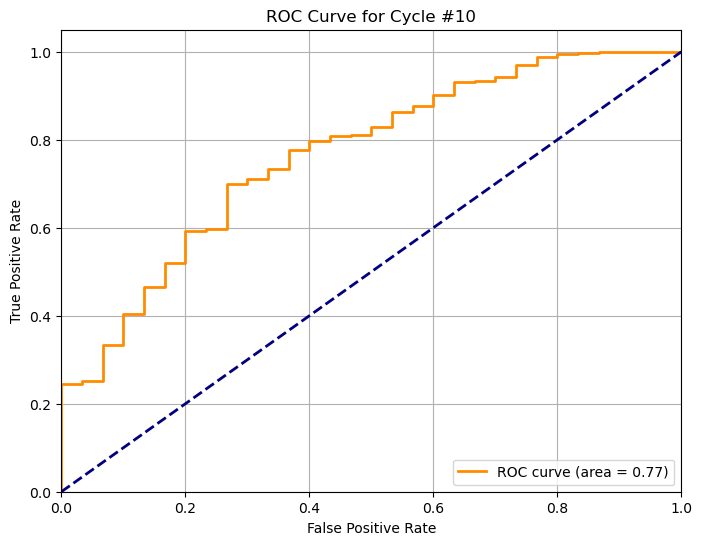

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# --- Metrics and plotting libraries ---
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

# --- Your main loop starts here ---
for i in range(1,11):
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    smote = SMOTE(sampling_strategy=1, random_state=42)
    x1, y1 = smote.fit_resample(x1, y1)
    display(pd.DataFrame(x1))

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()

    display("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        j["gamma"]= j["gamma"] if j["gamma"] == 'auto' or j["gamma"] == 'scale' else float(j["gamma"])
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        display(mcc)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)
    # Get binary predictions

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    display("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        display(mcc)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.

    pred = pred_test_knn[-1]
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE KNN#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)

    pred = pred_test_svc[-1]
    pred_proba = pred > 0.5
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE SVC#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)
        # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    for j in best_results_mlp_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        display(mcc)
        if mcc > best_mcc_this_run_mlp:
            best_mcc_this_run_mlp = mcc
            best_val_results_this_run_mlp = mlp.predict(x2)
            best_test_results_this_run_mlp = mlp.predict(x3)
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)
    # Get binary predictions


    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.
    pred_proba = pred_test_mlp[-1]
    print(pred_proba)
    pred = pred_proba > 0.5
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE MLP#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)



    plt.show() # This will display the plot for the current cycle

    print("="*30)
    # --- End: New code ---
    # --- End: New code ---



In [17]:
all_y3 =[]
mcc_list = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [18]:
display(mcc_list)

[0.2590673727071247,
 0.3798387800589918,
 0.391217119077599,
 0.19934263734829705,
 0.42466123528167465,
 0.19768650035745625,
 0.3211236989907789,
 0.2871095372856315,
 0.22732950863883472,
 0.17903199116373997]

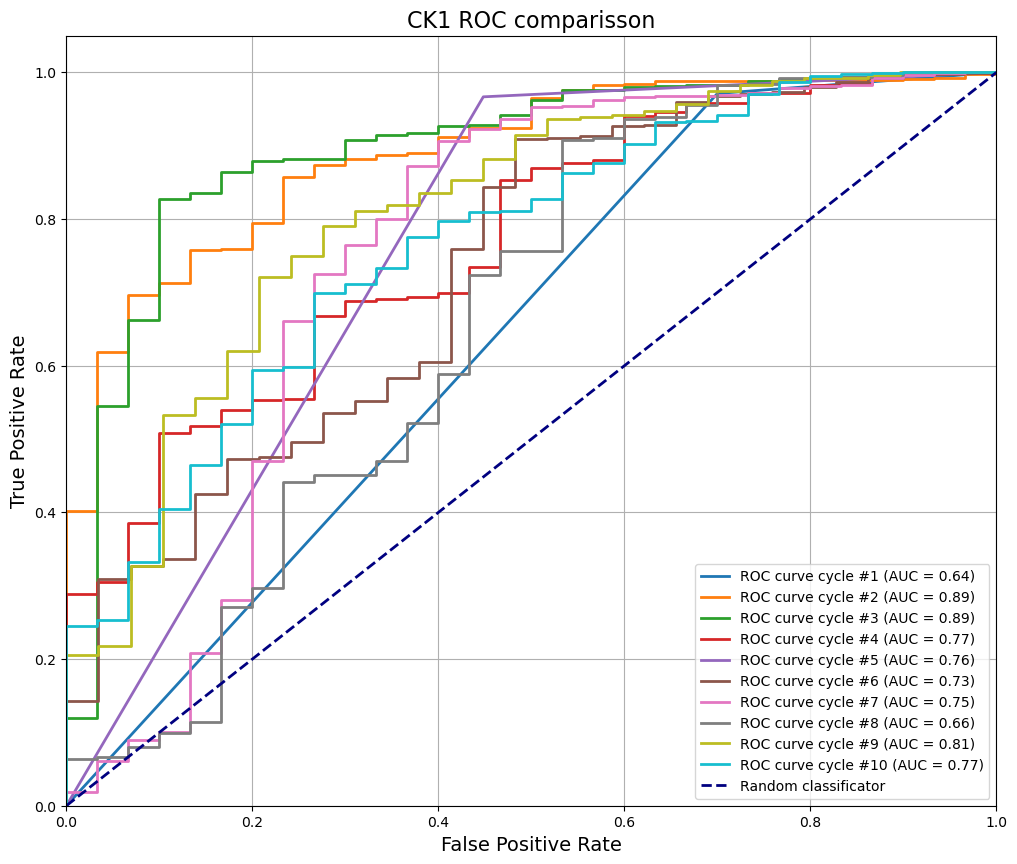

In [19]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"



plt.figure(figsize=(12, 10))

# Projdeme všechny uložené predikce a skutečné hodnoty
for i in range(len(pred_test_mlp)):
    
    # Získáme data pro i-tý cyklus
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    # Vypočítáme ROC křivku a AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Vykreslíme křivku pro tento cyklus do společného grafu
    # (i + 2) použijeme pro správné číslování cyklů, protože váš cyklus začínal od 2
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

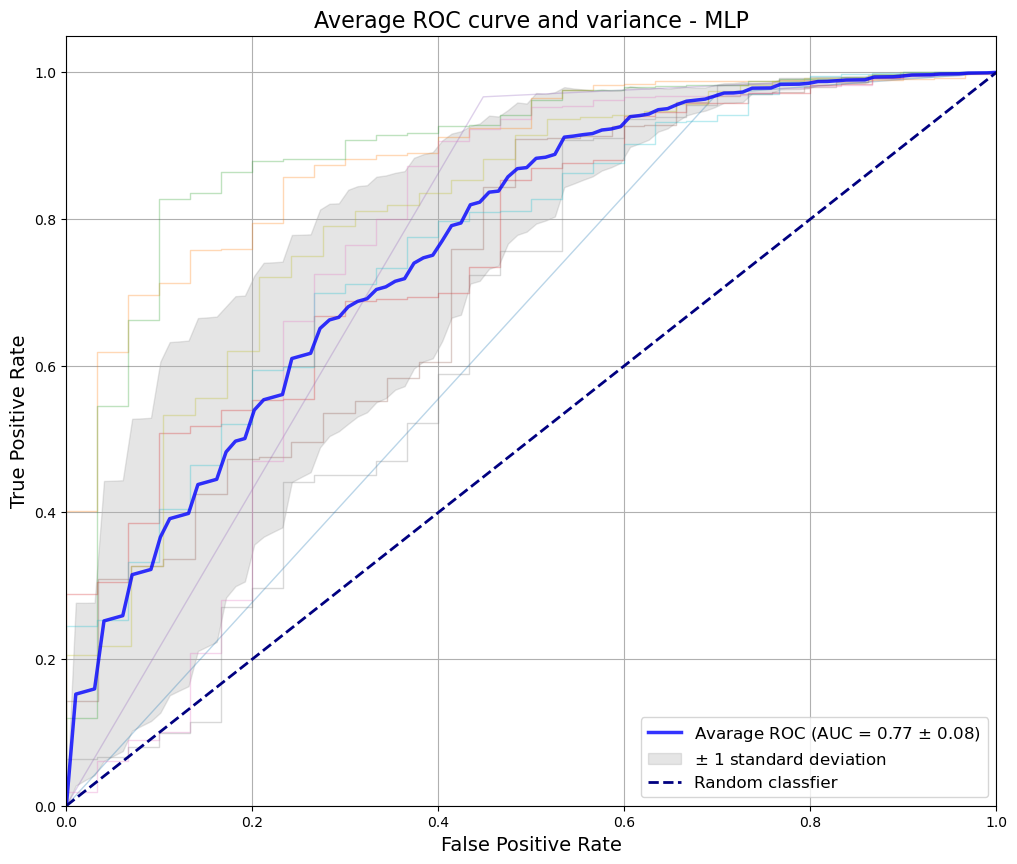

In [40]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('mcc_roc_a2ar.png', dpi=300, bbox_inches='tight')
plt.show()


In [36]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [37]:
all_y3_mlp =[]
mcc_list_mlp = []
f1_list_mlp = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp.append(y_test)
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    print(mcc_list_mlp[-1])

1
0.2590673727071247
2
0.3798387800589918
3
0.391217119077599
4
0.19934263734829705
5
0.42466123528167465
6
0.19768650035745625
7
0.3211236989907789
8
0.2871095372856315
9
0.22732950863883472
10
0.17903199116373997


In [38]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


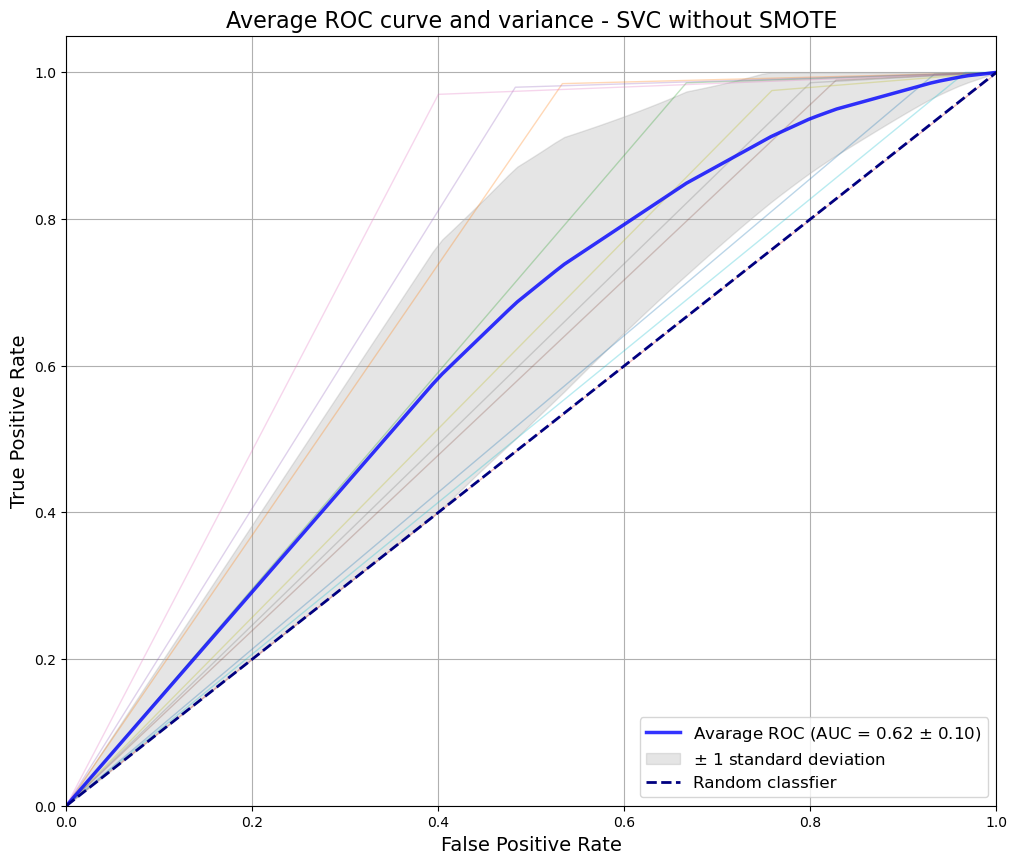

In [24]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3_svc[i]
    y_pred_proba = pred_test_svc[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - SVC without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

In [32]:
mcc_list_mlp_ws = [0.1281798780761299,
  0.27633194551789986,
  0.29321859804235006,
  0.14935675272967644,
  0.3122218820237701,
  0.18828640645456463,
  0.31953811194513976,
  0.16379161523982758,
  0.11243400302788535,
  0.1998145741868857]
mcc_list_knn_ws = [0.17332578285850453,
  0.17953019478623866,
  0.12403710255014591,
  -0.006307414036197334,
  0.1392570156212914,
  -0.006284578193275152,
  0.15223657127683576,
  0.4061637774155975,
  0.34173701316387467,
  0.08636823648308975]
mcc_list_svc_ws =  [0.4437119029360156,
  0.3264163477008382,
  0.3402164470726091,
  0.0,
  0.5751772174309716,
  0.2400299353933224,
  0.41642937883652664,
  0.33437662462636963,
  -0.008830963679450526,
  0.17371209956807496]





In [34]:
f1_list_mlp_ws = [0.9209361163820367,
  0.9186119873817035,
  0.9688249400479616,
  0.9153175591531756,
  0.931316950220542,
  0.9800235017626322,
  0.9464508094645081,
  0.9046114971572963,
  0.965026674570243,
  0.9759725400457666]
f1_list_knn_ws =  [0.9822904368358913,
  0.9831884057971014,
  0.9806678383128296,
  0.982153137593552,
  0.9817968291250734,
  0.9824970828471412,
  0.9817109144542773,
  0.9855240301100173,
  0.9848837209302326,
  0.9784090909090909]
f1_list_svc_ws =   [0.9857988165680474,
  0.9824766355140186,
  0.9829512051734274,
  0.9827387802071347,
  0.9881796690307328,
  0.9836257309941521,
  0.9852158486102898,
  0.9837587006960556,
  0.9820289855072464,
  0.9830316742081447]









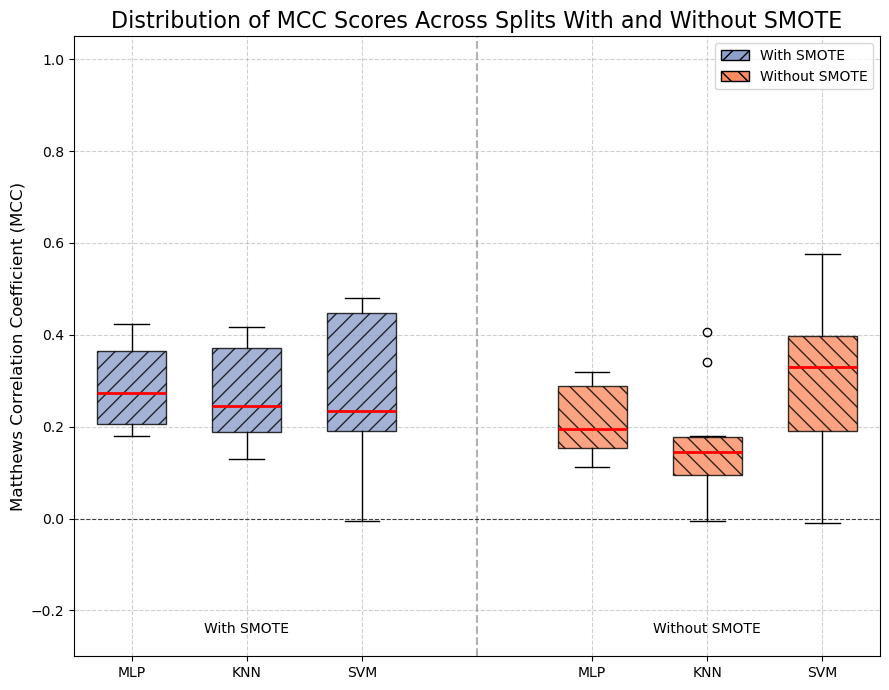

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(9, 7))

# Data
data = [mcc_list_mlp, mcc_list_knn, mcc_list_svc,
        mcc_list_mlp_ws, mcc_list_knn_ws, mcc_list_svc_ws]

# Vlastní pozice pro mezery mezi skupinami
positions = [1, 2, 3, 5, 6, 7]

# Vykreslení boxplotu na definovaných pozicích
bplot = plt.boxplot(data,
                    positions=positions,
                    patch_artist=True,
                    widths=0.6)

# Barvy a šrafování
smote_color = '#8da0cb'
non_smote_color = '#fc8d62'
smote_hatch = '//'
non_smote_hatch = '\\\\'
median_color = 'red'

# Úprava boxů
for i, box in enumerate(bplot['boxes']):
    if i < 3:
        box.set_facecolor(smote_color)
        box.set_hatch(smote_hatch)
    else:
        box.set_facecolor(non_smote_color)
        box.set_hatch(non_smote_hatch)
    box.set_edgecolor('black')
    box.set_alpha(0.8)

# Mediány
for median in bplot['medians']:
    median.set_color(median_color)
    median.set_linewidth(2)

# X-osa – popisky
plt.xticks([1, 2, 3, 5, 6, 7], ['MLP', 'KNN', 'SVM', 'MLP', 'KNN', 'SVM'])

# Oddělující čára mezi skupinami
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.6)
plt.text(2, -0.25, 'With SMOTE', ha='center', fontsize=10)
plt.text(6, -0.25, 'Without SMOTE', ha='center', fontsize=10)

# Titulek a osy
plt.title('Distribution of MCC Scores Across Splits With and Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
plt.ylim([-0.3, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Add a horizontal line at MCC = 0
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Legenda
smote_patch = mpatches.Patch(facecolor=smote_color, edgecolor='black', hatch=smote_hatch, label='With SMOTE')
non_smote_patch = mpatches.Patch(facecolor=non_smote_color, edgecolor='black', hatch=non_smote_hatch, label='Without SMOTE')
plt.legend(handles=[smote_patch, non_smote_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('mcc_boxplot_a2ar.png', dpi=300, bbox_inches='tight')
plt.show()


In [27]:
display(mcc_list_knn)

[0.2072677441862618,
 0.37352946342206256,
 0.36825790882958453,
 0.16804819554490985,
 0.3897588772161016,
 0.1939215293129892,
 0.4166885012122133,
 0.28227009324524993,
 0.1864826984992425,
 0.12940610666034935]

In [28]:
display(mcc_list_svc)

[0.17332578285850453,
 0.4749111071569855,
 0.37084938695826003,
 -0.006307414036197334,
 0.4739801807861051,
 0.23073645555342742,
 0.4799038187619209,
 0.23834326450959173,
 0.22034930688077975,
 0.17960862802009056]

In [29]:
display(mcc_list_mlp)

[0.2590673727071247,
 0.3798387800589918,
 0.391217119077599,
 0.19934263734829705,
 0.42466123528167465,
 0.19768650035745625,
 0.3211236989907789,
 0.2871095372856315,
 0.22732950863883472,
 0.17903199116373997]

In [30]:
display(mcc_list_mlp_ws)

[0.362012716495486,
 0.27633194551789986,
 0.29321859804235006,
 0.14935675272967644,
 0.3122218820237701,
 0.18828640645456463,
 0.31953811194513976,
 0.16379161523982758,
 0.11243400302788535,
 0.1998145741868857]

TypeError: missing a required argument: 'y_pred'

In [70]:
display(pred_test_mlp[:][0])

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],

In [39]:
import pandas as pd
import numpy as np


def create_string(list_vals):
    return f"{np.mean(list_vals):.4f} ± {np.var(list_vals, ddof=1):.4f}"
# Příklad dat
data = {
    "Model": ["MLP", "MLP without SMOTE", "KNN", "KNN without SMOTE", "SVM", "SVM without SMOTE"],
    "F1": [create_string(f1_list_mlp), create_string(f1_list_mlp_ws), create_string(f1_list_knn), create_string(f1_list_knn_ws), create_string(f1_list_svc), create_string(f1_list_svc_ws)],
    "MCC": [create_string(mcc_list_mlp), create_string(mcc_list_mlp_ws), create_string(mcc_list_knn), create_string(mcc_list_knn_ws), create_string(mcc_list_svc), create_string(mcc_list_svc_ws)]
}


df = pd.DataFrame(data)
print(df)
latex_code = df.to_latex(index=False, escape=False)
print(latex_code)

               Model               F1              MCC
0                MLP  0.9737 ± 0.0000  0.2866 ± 0.0079
1  MLP without SMOTE  0.9427 ± 0.0008  0.2143 ± 0.0062
2                KNN  0.9737 ± 0.0000  0.2716 ± 0.0115
3  KNN without SMOTE  0.9823 ± 0.0000  0.1590 ± 0.0174
4                SVM  0.9806 ± 0.0000  0.2836 ± 0.0261
5  SVM without SMOTE  0.9840 ± 0.0000  0.2841 ± 0.0351
\begin{tabular}{lll}
\toprule
Model & F1 & MCC \\
\midrule
MLP & 0.9737 ± 0.0000 & 0.2866 ± 0.0079 \\
MLP without SMOTE & 0.9427 ± 0.0008 & 0.2143 ± 0.0062 \\
KNN & 0.9737 ± 0.0000 & 0.2716 ± 0.0115 \\
KNN without SMOTE & 0.9823 ± 0.0000 & 0.1590 ± 0.0174 \\
SVM & 0.9806 ± 0.0000 & 0.2836 ± 0.0261 \\
SVM without SMOTE & 0.9840 ± 0.0000 & 0.2841 ± 0.0351 \\
\bottomrule
\end{tabular}

